[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/10_pandas_sql/10_4_GROUP_BY.ipynb)

# 10.4: `GROUP BY` and `HAVING`

Filtering rows with `WHERE` answers questions like "which countries had a life expectancy above 70 in 2007?" But many business questions are about groups, not individual rows: "what is the average life expectancy per continent?" or "which continents had more than 20 countries in the dataset?" These questions require aggregation, collapsing multiple rows into a single summary value for each group.

In module 09 you used `groupby().agg()` in pandas. SQL has a direct equivalent: `GROUP BY` with aggregate functions. The logic is the same; the syntax is different.

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_parquet("gapminder.parquet")

countries = df[["country", "continent"]].drop_duplicates().reset_index(drop=True)
measurements = df[["country", "year", "lifeExp", "pop", "gdpPercap"]].copy()

conn = sqlite3.connect(":memory:")
countries.to_sql("countries", conn, index=False, if_exists="replace")
measurements.to_sql("measurements", conn, index=False, if_exists="replace")

print("Ready.")

## `GROUP BY`: the SQL equivalent of `groupby().agg()`

In pandas you wrote `df.groupby("continent")["lifeExp"].mean()` to get the mean life expectancy per continent. In SQL, the same idea splits across two parts of the query: the grouping key goes in `GROUP BY`, and the aggregation goes in `SELECT` using an aggregate function.

Let's start with the simplest possible case, counting rows per year, to see the structure clearly before adding more complexity.

In [2]:
pd.read_sql("""
    SELECT year, COUNT(*) AS n_rows
    FROM measurements
    GROUP BY year
    ORDER BY year
""", conn)

,year,n_rows
0,1952,142
1,1957,142
2,1962,142
3,1967,142
4,1972,142
5,1977,142
6,1982,142
7,1987,142
8,1992,142
9,1997,142


142 rows per year, one for each country, confirming the panel structure of the dataset. `COUNT(*)` counts every row in the group regardless of null values. `AS n_rows` gives the aggregated column a readable name. Without the alias, the column header would be `COUNT(*)`, which is technically correct but harder to work with downstream.

Notice that `year` appears in both `SELECT` and `GROUP BY`. This is a SQL requirement: every column in the `SELECT` list that is not wrapped in an aggregate function must also appear in `GROUP BY`. If you group by year, the query needs to know what to do with every other column, and any column not in `GROUP BY` must be aggregated. Pandas handles this automatically; SQL requires you to be explicit.

## Aggregate functions: `AVG`, `SUM`, `MIN`, `MAX`

SQL provides five standard aggregate functions that map directly to what you already know from pandas:

| SQL | pandas equivalent |
|---|---|
| `COUNT(*)` | `.size()` |
| `COUNT(col)` | `.count()` (non-null values only) |
| `AVG(col)` | `.mean()` |
| `SUM(col)` | `.sum()` |
| `MIN(col)` | `.min()` |
| `MAX(col)` | `.max()` |

You can use several in the same query. Here is a continent-level summary for 2007:

In [3]:
pd.read_sql("""
    SELECT c.continent,
           COUNT(*) AS n_countries,
           AVG(m.lifeExp) AS avg_life,
           MIN(m.lifeExp) AS min_life,
           MAX(m.lifeExp) AS max_life,
           AVG(m.gdpPercap) AS avg_gdp
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    WHERE m.year = 2007
    GROUP BY c.continent
    ORDER BY avg_life DESC
""", conn).round(1)

,continent,n_countries,avg_life,min_life,max_life,avg_gdp
0,Oceania,2,80.7,80.2,81.2,29810.2
1,Europe,30,77.6,71.8,81.8,25054.5
2,Americas,25,73.6,60.9,80.7,11003.0
3,Asia,33,70.7,43.8,82.6,12473.0
4,Africa,52,54.8,39.6,76.4,3089.0


This single query does the work of the named-aggregation call from module 09: mean, min, max, and count, all in one result, one row per continent, sorted by mean life expectancy. Oceania's two-country average of 80.7 is the highest; Africa's 54.8 is the lowest, with a range from 39.6 to 76.4 that reveals enormous internal variation.

The query also uses a `JOIN` for the first time in the GROUP BY context, because continent lives in the `countries` table, not in `measurements`. Notebook 10.5 covers JOIN in depth; for now, just notice that the WHERE, GROUP BY, and aggregate functions compose naturally regardless of how many tables are involved.

## `COUNT(DISTINCT col)`: counting unique values

`COUNT(*)` counts rows. `COUNT(DISTINCT col)` counts how many distinct values appear in a column within each group. This is the SQL equivalent of `nunique()` in pandas, and it comes up whenever you want to know "how many unique items" rather than "how many rows."

In [4]:
# How many distinct countries in each continent? (across all years)
pd.read_sql("""
    SELECT c.continent,
           COUNT(DISTINCT m.country) AS n_countries
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    GROUP BY c.continent
    ORDER BY n_countries DESC
""", conn)

,continent,n_countries
0,Africa,52
1,Asia,33
2,Europe,30
3,Americas,25
4,Oceania,2


Africa has 52 countries, Asia 33, and Oceania just 2. If we had used `COUNT(*)` instead of `COUNT(DISTINCT country)`, each country would have been counted 12 times (once per year), giving Africa 624 instead of 52. The distinction between counting rows and counting unique values is one of the most common sources of errors in aggregate queries.

| pandas | SQL |
|---|---|
| `groupby("continent")["country"].nunique()` | `COUNT(DISTINCT country)` |

## Grouping by multiple columns

Just as pandas allows `groupby(["continent", "year"])`, SQL allows `GROUP BY continent, year`. The result has one row per unique combination of the grouping keys.

In [5]:
# Mean life expectancy per continent per decade endpoint
multi_group = pd.read_sql("""
    SELECT c.continent,
           m.year,
           ROUND(AVG(m.lifeExp), 1) AS avg_life
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    WHERE m.year IN (1952, 1972, 1992, 2007)
    GROUP BY c.continent, m.year
    ORDER BY c.continent, m.year
""", conn)
multi_group

,continent,year,avg_life
0,Africa,1952,39.1
1,Africa,1972,47.5
2,Africa,1992,53.6
3,Africa,2007,54.8
4,Americas,1952,53.3
5,Americas,1972,62.4
6,Americas,1992,69.6
7,Americas,2007,73.6
8,Asia,1952,46.3
9,Asia,1972,57.3


The ROUND() function is a scalar function, operating on one value at a time rather than on a group, so it can wrap an aggregate expression directly in SQL. The result shows 20 rows: 5 continents times 4 years. Africa's stagnation in 1992 (53.4) versus its 1972 value (47.5) shows slower progress than you might expect from the global trend.

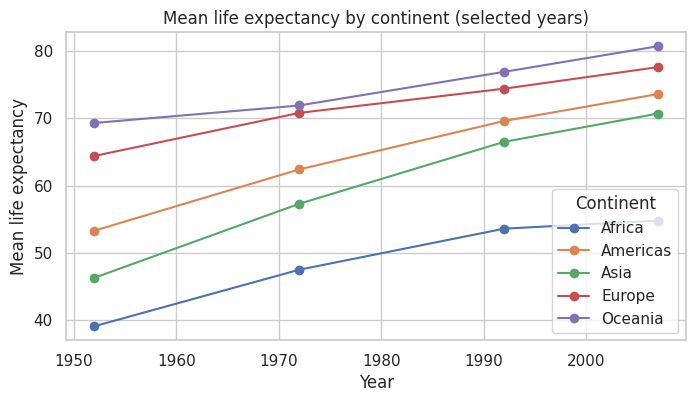

In [6]:
# The SQL result is a regular DataFrame; chart it directly
fig, ax = plt.subplots(figsize=(8, 4))
for continent, group in multi_group.groupby("continent"):
    ax.plot(group["year"], group["avg_life"], marker="o", label=continent)
ax.set_title("Mean life expectancy by continent (selected years)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean life expectancy")
ax.legend(title="Continent")

The query result is a plain DataFrame, so it works with any pandas or seaborn visualization immediately. Europe and Oceania climb steadily; Asia shows the steepest gain; Africa's line is much flatter than the others and actually dips slightly between 1972 and 1992. This is the `pd.read_sql()` pattern at its most useful: SQL does the aggregation across 1,704 rows, and Python does the charting.

## `HAVING`: filtering after aggregation

Here is a question `WHERE` cannot answer: "Which continents had an average GDP per capita above $10,000 in 2007?" The average GDP per capita does not exist as a value in any row; it is computed during aggregation. `WHERE` filters rows before grouping happens, so it cannot reference aggregate results.

`HAVING` is the clause designed for this: it filters groups after the aggregation is complete. It is the SQL equivalent of `groupby().filter()` from module 09.

In [7]:
# WHERE cannot filter on an aggregate (this query will error)
try:
    pd.read_sql("""
        SELECT c.continent, AVG(m.gdpPercap) AS avg_gdp
        FROM measurements AS m
        JOIN countries AS c ON m.country = c.country
        WHERE m.year = 2007
          AND AVG(m.gdpPercap) > 10000
        GROUP BY c.continent
    """, conn)
except Exception as e:
    print(f"Error: {e}")

Error: Execution failed on sql '
        SELECT c.continent, AVG(m.gdpPercap) AS avg_gdp
        FROM measurements AS m
        JOIN countries AS c ON m.country = c.country
        WHERE m.year = 2007
          AND AVG(m.gdpPercap) > 10000
        GROUP BY c.continent
    ': misuse of aggregate: AVG()


The database raises a "misuse of aggregate function" error because `AVG()` cannot appear inside `WHERE`. The database evaluates `WHERE` before it has computed any groups or aggregates; there is no average to compare against yet.

The fix is to move the aggregate condition to `HAVING`, which runs after `GROUP BY`.

In [8]:
pd.read_sql("""
    SELECT c.continent,
           ROUND(AVG(m.gdpPercap), 0) AS avg_gdp,
           COUNT(DISTINCT m.country) AS n_countries
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    WHERE m.year = 2007
    GROUP BY c.continent
    HAVING AVG(m.gdpPercap) > 20000
    ORDER BY avg_gdp DESC
""", conn)

,continent,avg_gdp,n_countries
0,Oceania,29810.0,2
1,Europe,25054.0,30


Oceania and Europe are the only two continents where the average GDP per capita across all member countries exceeded $20,000 in 2007. The other three continents fall below that threshold. This is exactly what `HAVING` is designed for: the average does not exist as a row value anywhere in the raw data; it is produced by the aggregation, and `HAVING` tests it after that aggregation is complete.

In [9]:
pd.read_sql("""
    SELECT c.continent,
           ROUND(AVG(m.gdpPercap), 0) AS avg_gdp
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    WHERE m.year = 2007
    GROUP BY c.continent
    ORDER BY avg_gdp DESC
""", conn)

,continent,avg_gdp
0,Oceania,29810.0
1,Europe,25054.0
2,Asia,12473.0
3,Americas,11003.0
4,Africa,3089.0


Without the `HAVING` filter, all five continents appear. Africa has the lowest average GDP per capita at $3,089, followed by Asia ($12,473) and the Americas ($11,003). Only Oceania ($29,810) and Europe ($25,054) exceed the $20,000 threshold used above. Comparing the filtered result to this complete picture confirms that `HAVING` is working correctly: it kept exactly the two continents above the threshold and dropped the other three.

## `WHERE` and `HAVING` together

A realistic query often uses both: `WHERE` to restrict which rows enter the aggregation, and `HAVING` to restrict which groups appear in the result. The SQL clause order is always:

```
SELECT   ...
FROM     ...
WHERE    ...     ← filters rows before grouping
GROUP BY ...
HAVING   ...     ← filters groups after aggregation
ORDER BY ...
LIMIT    ...
```

In [ ]:
pd.read_sql("""
    SELECT country,
           COUNT(*) AS n_years,
           ROUND(AVG(lifeExp), 1) AS avg_life,
           ROUND(MIN(lifeExp), 1) AS min_life
    FROM measurements
    WHERE year > 1980
    GROUP BY country
    HAVING AVG(lifeExp) > 75
       AND MIN(lifeExp) > 76
    ORDER BY avg_life DESC
    LIMIT 15
""", conn)

The `WHERE year > 1980` clause removed all pre-1981 observations before any aggregation happened. The `HAVING` clause then applied two conditions to the remaining groups: the group average exceeded 75 AND the group minimum exceeded 76. That second condition does real filtering work: Australia (min 74.7), Canada (min 75.8), France (min 74.9), and Italy (min 75.0) are absent despite averaging above 75, because their 1982 life expectancy fell below the minimum threshold. The countries that survive both conditions are those where high life expectancy was already the norm in 1982, not just a recent achievement. Japan, Iceland, and Switzerland top the list.

This is the WHERE and HAVING division at its clearest: `WHERE` restricts which rows enter the aggregation; `HAVING` restricts which groups the aggregated result returns.

## Updated translation table

| Goal | pandas | SQL |
|---|---|---|
| Select columns | `df[["a", "b"]]` | `SELECT a, b FROM table` |
| Filter rows | `df.query("col > x")` | `WHERE col > x` |
| Sort | `df.sort_values("col")` | `ORDER BY col` |
| First N rows | `df.head(N)` | `LIMIT N` |
| Count rows per group | `groupby(col).size()` | `SELECT col, COUNT(*) ... GROUP BY col` |
| Mean per group | `groupby(col)["val"].mean()` | `SELECT col, AVG(val) ... GROUP BY col` |
| Multiple aggregations | `.agg(["mean", "min", "max"])` | `AVG(), MIN(), MAX()` in SELECT |
| Count distinct | `.nunique()` | `COUNT(DISTINCT col)` |
| Filter groups | `groupby(col).filter(lambda g: ...)` | `HAVING condition` |

## What's next

You can now filter rows, group them, aggregate across groups, and filter those groups. The one thing missing is the ability to combine information from two tables in a single query. In notebook 10.5 you will learn `JOIN`, how to merge the `countries` and `measurements` tables in SQL, and how it corresponds to `merge()` in pandas.